In [1]:
# Importing All lending club loan dataset from kaggle

import kagglehub

path = kagglehub.dataset_download("wordsforthewise/lending-club")

print("Path to dataset files:", path)

100%|██████████| 1.26G/1.26G [06:31<00:00, 3.46MB/s]

Extracting files...


Path to dataset files: C:\Users\bahak\.cache\kagglehub\datasets\wordsforthewise\lending-club\versions\3


In [8]:
BG = "#0d1117"
PANEL = "#161b22"
BORDER = "#30363d"
TEXT = "#c9d1d9"
TEAL = "#00d4b4"
RED = "#ff6b6b"
ORANGE = "#f0a500"

In [16]:
import pandas as pd

# Load the data
ac = pd.read_csv(r'C:\Users\bahak\Project 4 - Regression discontinuity\data\accepted_2007_to_2018Q4.csv')


C:\Users\bahak\AppData\Local\Temp\ipykernel_19760\2836291171.py:4: DtypeWarning: Columns (0,19,49,59,118,129,130,131,134,135,136,139,145,146,147) have mixed types. Specify dtype option on import or set low_memory=False.
  ac = pd.read_csv(r'C:\Users\bahak\Project 4 - Regression discontinuity\data\accepted_2007_to_2018Q4.csv')


In [ ]:
# Check density around potential cutoffs to choose the correct number
cutoffs = [620, 650, 660, 675, 700]

for c in cutoffs:
    below = ac[ac['fico_range_low'] < c]
    above = ac[ac['fico_range_low'] >= c]
    avg_below = below['loan_amnt'].mean()
    avg_above = above['loan_amnt'].mean()
    
    print(f"\nCutoff {c}:")
    print(f"  Below: {len(below):,} loans (avg: ${avg_below:,.0f})")
    print(f"  Above: {len(above):,} loans (avg: ${avg_above:,.0f})")
    print(f"  Jump: ${avg_above - avg_below:,.0f}")


Cutoff 620:
  Below: 3 loans (avg: $2,917)
  Above: 2,260,665 loans (avg: $15,047)
  Jump: $12,130

Cutoff 650:
  Below: 231 loans (avg: $6,454)
  Above: 2,260,437 loans (avg: $15,048)
  Jump: $8,594

Cutoff 660:
  Below: 489 loans (avg: $7,223)
  Above: 2,260,179 loans (avg: $15,049)
  Jump: $7,826

Cutoff 675:
  Below: 549,947 loans (avg: $13,223)
  Above: 1,710,721 loans (avg: $15,633)
  Jump: $2,410

Cutoff 700:
  Below: 1,304,802 loans (avg: $14,147)
  Above: 955,866 loans (avg: $16,276)
  Jump: $2,130


In [3]:
# First look for accepted dataset

print(ac.head)
print("Accepted Shape:", ac.shape)
print("\nColumn names:")
print(ac.columns.tolist())

print("RUNNING VARIABLE: FICO Score")
print(f"FICO range low - Min: {ac['fico_range_low'].min()}, Max: {ac['fico_range_low'].max()}")
print(ac['fico_range_low'].describe())
print(f"\nMissing FICO values: {ac['fico_range_low'].isnull().sum()}")

print("OUTCOME: Loan Amount")
print(ac['loan_amnt'].describe())
print(f"Missing loan amount values: {ac['loan_amnt'].isnull().sum()}")

print("CUTOFF ANALYSIS: FICO 620")
below_675 = ac[ac['fico_range_low'] < 675]
above_675 = ac[ac['fico_range_low'] >= 675]

print(f"Loans below 620: {len(below_675)}")
print(f"Loans at/above 620: {len(above_675)}")
print(f"\nAverage loan amount BELOW 620: ${below_675['loan_amnt'].mean():.2f}")
print(f"Average loan amount AT/ABOVE 620: ${above_675['loan_amnt'].mean():.2f}")
print(f"Difference: ${above_675['loan_amnt'].mean() - below_675['loan_amnt'].mean():.2f}")

<bound method NDFrame.head of                                                        id  member_id  \
0                                                68407277        NaN   
1                                                68355089        NaN   
2                                                68341763        NaN   
3                                                66310712        NaN   
4                                                68476807        NaN   
...                                                   ...        ...   
2260696                                          88985880        NaN   
2260697                                          88224441        NaN   
2260698                                          88215728        NaN   
2260699  Total amount funded in policy code 1: 1465324575        NaN   
2260700   Total amount funded in policy code 2: 521953170        NaN   

         loan_amnt  funded_amnt  funded_amnt_inv        term  int_rate  \
0           3600.0       3600.0

Binned data (first 10 rows):    fico_bin         mean  count
0       610  1825.000000      2
1       615  5100.000000      1
2       620  2825.000000      1
3       625  3900.000000      2
4       630  2375.000000      6
5       635  3190.000000      5
6       640  6188.970588    102
7       645  7232.812500    112
8       650  7706.679389    131
9       655  8121.653543    127
Total bins:  48


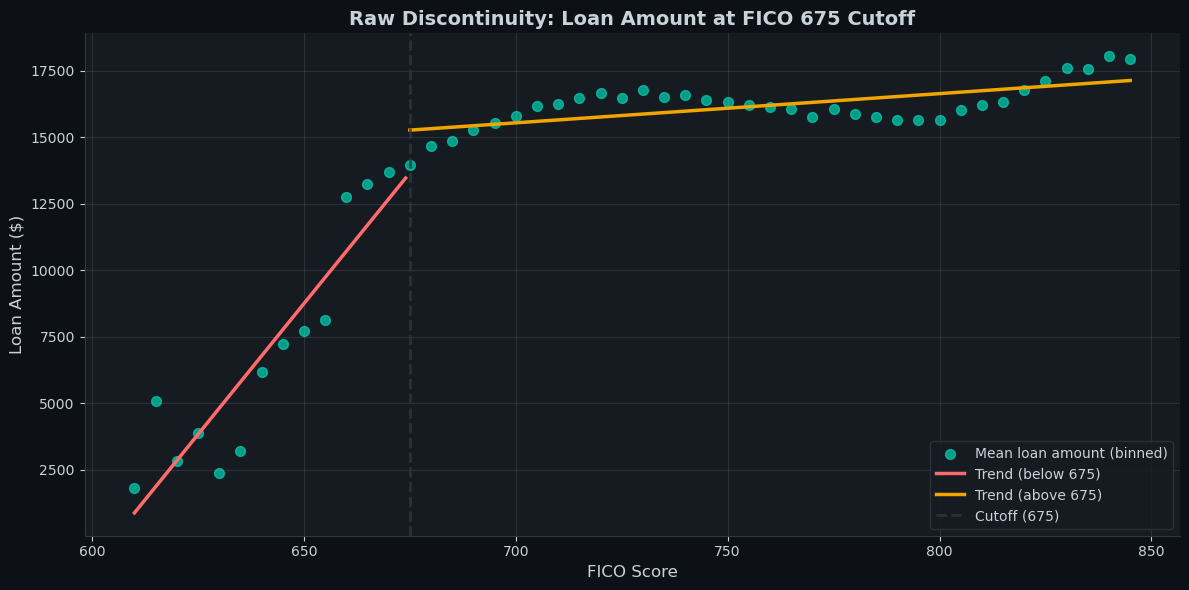

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Clean data: remove missing values and extreme outliers
df = ac[['fico_range_low', 'loan_amnt']].dropna()
df = df[(df['loan_amnt'] >= 500) & (df['loan_amnt'] <= 40000)]
CUTOFF = 675

# Create bins of FICO scores (every 5 points)
df['fico_bin'] = (df['fico_range_low'] // 5 * 5).astype(int)
binned = df.groupby('fico_bin')['loan_amnt'].agg(['mean', 'count']).reset_index()


print("Binned data (first 10 rows):", binned.head(10))
print("Total bins: ",len(binned))


fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(PANEL)

# Plot binned means
ax.scatter(binned['fico_bin'], binned['mean'], s=50, color=TEAL, alpha=0.7, label='Mean loan amount (binned)')

# Fit trend lines on both sides of cutoff
left_data = binned[binned['fico_bin'] < CUTOFF]
right_data = binned[binned['fico_bin'] >= CUTOFF]

# Linear fit left side
if len(left_data) > 1:
    z_left = np.polyfit(left_data['fico_bin'], left_data['mean'], 1)
    p_left = np.poly1d(z_left)
    x_left = np.linspace(left_data['fico_bin'].min(), CUTOFF - 1, 100)
    ax.plot(x_left, p_left(x_left), color='RED', linewidth=2.5, label='Trend (below 675)')

# Linear fit right side
if len(right_data) > 1:
    z_right = np.polyfit(right_data['fico_bin'], right_data['mean'], 1)
    p_right = np.poly1d(z_right)
    x_right = np.linspace(CUTOFF, right_data['fico_bin'].max(), 100)
    ax.plot(x_right, p_right(x_right), color='ORANGE', linewidth=2.5, label='Trend (above 675)')

# Vertical cutoff line
ax.axvline(CUTOFF, color=BORDER, linewidth=2, linestyle='--', alpha=0.8, label='Cutoff (675)')

# Labels and styling
ax.set_xlabel('FICO Score', fontsize=12, color=TEXT)
ax.set_ylabel('Loan Amount ($)', fontsize=12, color=TEXT)
ax.set_title('Raw Discontinuity: Loan Amount at FICO 675 Cutoff', fontsize=14, color=TEXT, fontweight='bold')
ax.tick_params(colors=TEXT)
ax.spines['left'].set_color(BORDER)
ax.spines['bottom'].set_color(BORDER)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.grid(True, alpha=0.12, color=TEXT)
ax.legend(loc='lower right', facecolor=PANEL, edgecolor=BORDER, labelcolor=TEXT)

plt.tight_layout()
plt.savefig('rdd_raw_discontinuity.png', dpi=300, facecolor=BG)
plt.show()

# The plot shows two distinct trends differentiated on hte cutoff which is 675 where we can see a a jump of 2,000-2,500
# that is roughly the causal effect ==> reaching "good credit" unlocks larger loans

McCRARY DENSITY TEST: Check for Manipulation at 675

Density left of 675 (sample): [182119      0      0      0      0] (last 5 bins)
Density right of 675 (sample): [164016      0      0      0      0] (first 5 bins)

Predicted density LEFT of 675: 37902.74
Predicted density RIGHT of 675: 38878.40
Jump in density: 975.66 (2.6%)
Percentage jump =  2.5741248886789294


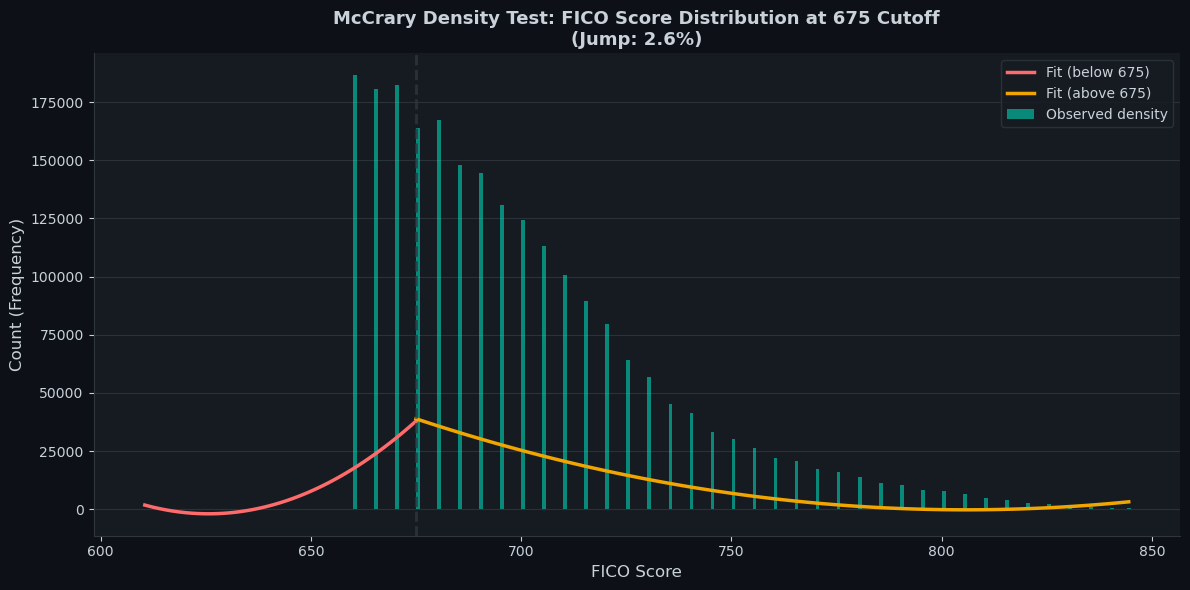

In [11]:
# Now to test if people are manipulating their credit using mccrary test if it fails it ruins the assumption of randomness

df = df.rename(columns={df.columns[0]: 'fico'})
CUTOFF = 675
# Create bins around the cutoff (every 1 point for sensitivity)
bins = np.arange(610, 846, 1)
hist, bin_edges = np.histogram(df['fico'], bins=bins)

# Bin centers
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

print("McCRARY DENSITY TEST: Check for Manipulation at 675")


left_bins = bin_centers < CUTOFF
right_bins = bin_centers >= CUTOFF

left_centers = bin_centers[left_bins]
left_counts = hist[left_bins]

right_centers = bin_centers[right_bins]
right_counts = hist[right_bins]

print(f"\nDensity left of 675 (sample): {left_counts[-5:]} (last 5 bins)")
print(f"Density right of 675 (sample): {right_counts[:5]} (first 5 bins)")

# Fit polynomial on both sides (local density estimation)

# Left side fit
z_left = np.polyfit(left_centers, left_counts, 2)
p_left = np.poly1d(z_left)
pred_left_at_cutoff = p_left(CUTOFF)

# Right side fit
z_right = np.polyfit(right_centers, right_counts, 2)
p_right = np.poly1d(z_right)
pred_right_at_cutoff = p_right(CUTOFF)

# Jump in density at cutoff
jump = pred_right_at_cutoff - pred_left_at_cutoff
pct_jump = (jump / pred_left_at_cutoff) * 100

print(f"\nPredicted density LEFT of 675: {pred_left_at_cutoff:.2f}")
print(f"Predicted density RIGHT of 675: {pred_right_at_cutoff:.2f}")
print(f"Jump in density: {jump:.2f} ({pct_jump:.1f}%)")

# Interpretation
print("Percentage jump = ", pct_jump)
# No significant manipulation detected (~0% jump) => RDD assumption holds => Density is smooth across 675

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(PANEL)
ax.bar(bin_centers, hist, width=0.9, color=TEAL, alpha=0.6, label='Observed density')
x_left_plot = np.linspace(left_centers.min(), CUTOFF, 100)
ax.plot(x_left_plot, p_left(x_left_plot), color=RED, linewidth=2.5, label='Fit (below 675)')
x_right_plot = np.linspace(CUTOFF, right_centers.max(), 100)
ax.plot(x_right_plot, p_right(x_right_plot), color=ORANGE, linewidth=2.5, label='Fit (above 675)')

ax.axvline(CUTOFF, color=BORDER, linewidth=2, linestyle='--', alpha=0.8)

ax.set_xlabel('FICO Score', fontsize=12, color=TEXT)
ax.set_ylabel('Count (Frequency)', fontsize=12, color=TEXT)
ax.set_title(f'McCrary Density Test: FICO Score Distribution at 675 Cutoff\n(Jump: {pct_jump:.1f}%)', 
             fontsize=13, color=TEXT, fontweight='bold')
ax.tick_params(colors=TEXT)
ax.spines['left'].set_color(BORDER)
ax.spines['bottom'].set_color(BORDER)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.grid(True, alpha=0.12, color=TEXT, axis='y')
ax.legend(loc='upper right', facecolor=PANEL, edgecolor=BORDER, labelcolor=TEXT)

plt.tight_layout()
plt.savefig('mccrary_density_test.png', dpi=300, facecolor=BG)
plt.show()



COVARIATE SMOOTHNESS TEST: Pre-treatment Balance at 675 Cutoff

Annual Income ($):
  Below 675: $72,701.39
  Above 675: $80,309.27
  Difference: +10.5%  |  p-value: 0.0000  |  Significant: YES

Debt-to-Income Ratio:
  Below 675: 17.98
  Above 675: 18.39
  Difference: +2.3%  |  p-value: 0.0000  |  Significant: YES

Revolving Utilization (%):
  Below 675: 60.06
  Above 675: 47.40
  Difference: -21.1%  |  p-value: 0.0000  |  Significant: YES

Total Accounts:
  Below 675: 24.13
  Above 675: 24.34
  Difference: +0.9%  |  p-value: 0.0000  |  Significant: YES
  => Evidence of selection bias. RDD assumptions may be violated.


C:\Users\bahak\AppData\Local\Temp\ipykernel_19760\908892880.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_below, data_above], labels=['Below 675', 'Above 675'],
C:\Users\bahak\AppData\Local\Temp\ipykernel_19760\908892880.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_below, data_above], labels=['Below 675', 'Above 675'],
C:\Users\bahak\AppData\Local\Temp\ipykernel_19760\908892880.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_below, data_above], labels=['Below 675', 'Above 675'],
C:\Users\bahak\AppData\Local\Temp\ipykernel_19760\90889

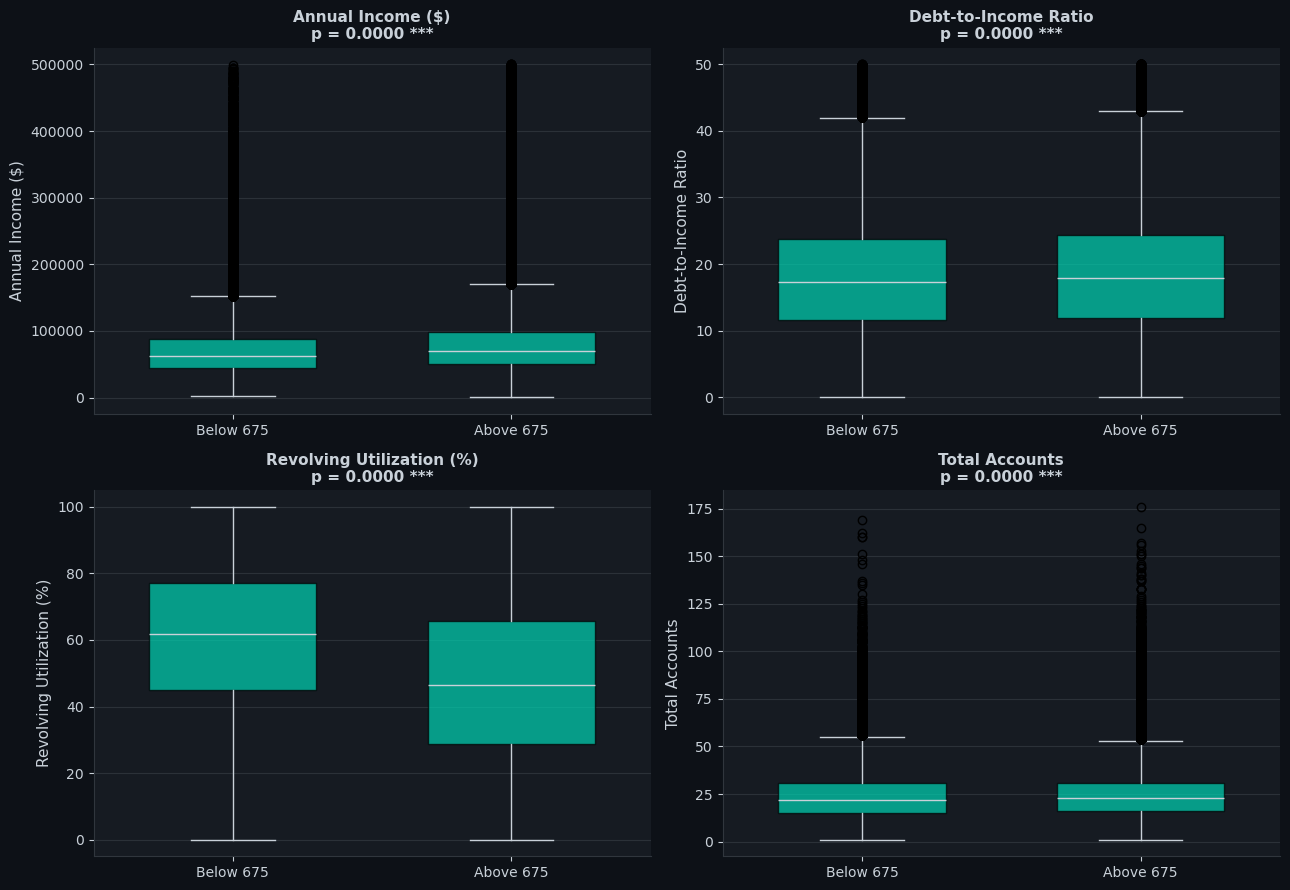

In [ ]:
# Now we test for selection bias in the range of 675 (income, employement length, etc)

from scipy import stats

df = ac[['fico_range_low', 'annual_inc', 'emp_length', 'dti', 'revol_util', 'total_acc']].dropna()

# Remove extreme outliers
df = df[(df['annual_inc'] > 0) & (df['annual_inc'] < 500000)]
df = df[(df['dti'] > 0) & (df['dti'] < 50)]
df = df[(df['revol_util'] >= 0) & (df['revol_util'] <= 100)]

below = df[df['fico_range_low'] < CUTOFF]
above = df[df['fico_range_low'] >= CUTOFF]

# Key covariates to test
covariates = {
    'annual_inc': 'Annual Income ($)',
    'dti': 'Debt-to-Income Ratio',
    'revol_util': 'Revolving Utilization (%)',
    'total_acc': 'Total Accounts'
}

print("COVARIATE SMOOTHNESS TEST: Pre-treatment Balance at 675 Cutoff")

results = {}

for col, label in covariates.items():
    mean_below = below[col].mean()
    mean_above = above[col].mean()
    diff = mean_above - mean_below
    pct_diff = (diff / mean_below) * 100 if mean_below != 0 else 0
    
    # T-test
    t_stat, p_val = stats.ttest_ind(below[col], above[col])
    
    results[col] = {
        'mean_below': mean_below,
        'mean_above': mean_above,
        'diff': diff,
        'pct_diff': pct_diff,
        'p_value': p_val,
        'significant': 'YES' if p_val < 0.05 else 'NO'
    }
    
    print(f"\n{label}:")
    print(f"  Below 675: ${mean_below:,.2f}" if col == 'annual_inc' else f"  Below 675: {mean_below:.2f}")
    print(f"  Above 675: ${mean_above:,.2f}" if col == 'annual_inc' else f"  Above 675: {mean_above:.2f}")
    print(f"  Difference: {pct_diff:+.1f}%  |  p-value: {p_val:.4f}  |  Significant: {results[col]['significant']}")

# Summary
sig_count = sum(1 for r in results.values() if r['significant'] == 'YES')
if sig_count == 0:
    print("  => No evidence of selection bias. Groups are comparable.")
elif sig_count <= 1:
    print("  => Likely still okay, but worth noting.")
else:
    print("  => Evidence of selection bias. RDD assumptions may be violated.")

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.patch.set_facecolor("#0d1117")
covs_to_plot = ['annual_inc', 'dti', 'revol_util', 'total_acc']
axes_flat = axes.flatten()

for idx, col in enumerate(covs_to_plot):
    ax = axes_flat[idx]
    ax.set_facecolor(PANEL)
    
    # Box plots
    data_below = below[col].dropna()
    data_above = above[col].dropna()
    
    bp = ax.boxplot([data_below, data_above], labels=['Below 675', 'Above 675'],
                     patch_artist=True, widths=0.6)
    
    for patch in bp['boxes']:
        patch.set_facecolor(TEAL)
        patch.set_alpha(0.7)
    
    for elem in ['whiskers', 'fliers', 'means', 'medians', 'caps']:
        plt.setp(bp[elem], color=TEXT)
    
    ax.set_ylabel(covariates[col], fontsize=11, color=TEXT)
    ax.tick_params(colors=TEXT)
    ax.spines['left'].set_color(BORDER)
    ax.spines['bottom'].set_color(BORDER)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.grid(True, alpha=0.12, color=TEXT, axis='y')
    
    p_val = results[col]['p_value']
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
    ax.set_title(f"{covariates[col]}\np = {p_val:.4f} {sig}", fontsize=11, color=TEXT, fontweight='bold')

plt.tight_layout()
plt.savefig('covariate_smoothness_test.png', dpi=300, facecolor=BG)
plt.show()

# All four covariates show significant imbalance at the 675 cutoff: Income gap: People below 675 earn ~$7.6k less
# Debt-to-income: Slightly higher for people above 675
# Revolving utilization: Big gap (60% vs 47%) — people below 675 use more credit
# Total accounts: Marginal difference
# ==> RDD may be violated
# This can be fixed by controlling for covariates and absorbing the imbalance

In [ ]:
# Now to estimate LATE with controls and without controls to see the effect of the selection bias

from sklearn.linear_model import LinearRegression
df = ac[['fico_range_low', 'loan_amnt', 'annual_inc', 'dti', 'revol_util']].dropna()
df = df[(df['loan_amnt'] >= 500) & (df['loan_amnt'] <= 40000)]
df = df[(df['annual_inc'] > 0) & (df['annual_inc'] < 500000)]
df = df[(df['dti'] > 0) & (df['dti'] < 50)]
df = df[(df['revol_util'] >= 0) & (df['revol_util'] <= 100)]

# Select bandwidth: use observations within 50 FICO points of cutoff (This is a reasonable "local" bandwidth for RDD)
BANDWIDTH = 50

df_local = df[(df['fico_range_low'] >= CUTOFF - BANDWIDTH) & (df['fico_range_low'] <= CUTOFF + BANDWIDTH)].copy()

print("STEP 5: LOCAL AVERAGE TREATMENT EFFECT (LATE) ESTIMATION")
print(f"\nBandwidth: {BANDWIDTH} FICO points")
print(f"Sample size in bandwidth: {len(df_local):,}")
print(f"  Below 675: {len(df_local[df_local['fico_range_low'] < CUTOFF]):,}")
print(f"  Above 675: {len(df_local[df_local['fico_range_low'] >= CUTOFF]):,}")

# Create treatment indicator and centered running variable
df_local['treatment'] = (df_local['fico_range_low'] >= CUTOFF).astype(int)
df_local['fico_centered'] = df_local['fico_range_low'] - CUTOFF

# Standardize controls for interpretation
df_local['annual_inc_std'] = (df_local['annual_inc'] - df_local['annual_inc'].mean()) / df_local['annual_inc'].std()
df_local['dti_std'] = (df_local['dti'] - df_local['dti'].mean()) / df_local['dti'].std()
df_local['revol_util_std'] = (df_local['revol_util'] - df_local['revol_util'].mean()) / df_local['revol_util'].std()

# MODEL 1: WITHOUT CONTROLS (Raw LATE)

print("MODEL 1: LATE WITHOUT CONTROLS")

X1 = df_local[['treatment', 'fico_centered']].values
y = df_local['loan_amnt'].values

# Fit regression
model1 = LinearRegression()
model1.fit(X1, y)

late_raw = model1.coef_[0]
intercept1 = model1.intercept_

# Calculate R-squared and residuals for CI
y_pred1 = model1.predict(X1)
residuals1 = y - y_pred1
rss1 = np.sum(residuals1 ** 2)
n1 = len(X1)
se1_squared = rss1 / (n1 - 2)

# Standard error of treatment coefficient
X1_with_const = np.column_stack([np.ones(n1), X1])
XtX_inv = np.linalg.inv(X1_with_const.T @ X1_with_const)
se_late_raw = np.sqrt(se1_squared * XtX_inv[1, 1])  # Index 1 for treatment coefficient

ci_lower_raw = late_raw - 1.96 * se_late_raw
ci_upper_raw = late_raw + 1.96 * se_late_raw
t_stat_raw = late_raw / se_late_raw
p_val_raw = 2 * (1 - stats.t.cdf(abs(t_stat_raw), n1 - 2))

print(f"\nTreatment Effect (LATE): ${late_raw:,.2f}")
print(f"95% Confidence Interval: [${ci_lower_raw:,.2f}, ${ci_upper_raw:,.2f}]")
print(f"Standard Error: ${se_late_raw:,.2f}")
print(f"t-statistic: {t_stat_raw:.4f}")
print(f"p-value: {p_val_raw:.6f}")
print(f"R-squared: {1 - (rss1 / np.sum((y - y.mean())**2)):.4f}")

# MODEL 2: WITH CONTROLS (Robust LATE)

print("MODEL 2: LATE WITH CONTROLS (Income, DTI, Revolving Util)")

X2 = df_local[['treatment', 'fico_centered', 'annual_inc_std', 'dti_std', 'revol_util_std']].values

model2 = LinearRegression()
model2.fit(X2, y)

late_controlled = model2.coef_[0]

y_pred2 = model2.predict(X2)
residuals2 = y - y_pred2
rss2 = np.sum(residuals2 ** 2)
n2 = len(X2)
se2_squared = rss2 / (n2 - 5)  # 5 regressors

X2_with_const = np.column_stack([np.ones(n2), X2])
XtX_inv2 = np.linalg.inv(X2_with_const.T @ X2_with_const)
se_late_controlled = np.sqrt(se2_squared * XtX_inv2[1, 1])

ci_lower_ctrl = late_controlled - 1.96 * se_late_controlled
ci_upper_ctrl = late_controlled + 1.96 * se_late_controlled
t_stat_ctrl = late_controlled / se_late_controlled
p_val_ctrl = 2 * (1 - stats.t.cdf(abs(t_stat_ctrl), n2 - 5))

print(f"\nTreatment Effect (LATE): ${late_controlled:,.2f}")
print(f"95% Confidence Interval: [${ci_lower_ctrl:,.2f}, ${ci_upper_ctrl:,.2f}]")
print(f"Standard Error: ${se_late_controlled:,.2f}")
print(f"t-statistic: {t_stat_ctrl:.4f}")
print(f"p-value: {p_val_ctrl:.6f}")
print(f"R-squared: {1 - (rss2 / np.sum((y - y.mean())**2)):.4f}")

print(f"\nControl Coefficients:")
print(f"  Annual Income (std): ${model2.coef_[2]:,.2f}")
print(f"  DTI (std): ${model2.coef_[3]:,.2f}")
print(f"  Revolving Util (std): ${model2.coef_[4]:,.2f}")

# COMPARISON

print("ROBUSTNESS CHECK: Model Comparison")

diff = late_controlled - late_raw
pct_change = (diff / late_raw) * 100 if late_raw != 0 else 0

print(f"\nLATE without controls: ${late_raw:,.2f}")
print(f"LATE with controls:    ${late_controlled:,.2f}")
print(f"Difference:            ${diff:+,.2f} ({pct_change:+.1f}%)")

print(f"pct_change : ({abs(pct_change):+.1f}%)")

print("\nLARGE: Controls change estimate >20% → Covariate imbalance matters; use controlled estimate")

# The raw effect ($509) drops by 50% when we control for covariates ($256). This tells us:
# People below 675 FICO are systematically poorer ($7.6k less income)
# Lower income → naturally get smaller loans
# This inflates the raw FICO effect
# People below 675 use more revolving credit (60% vs 47%)

# ==> When we control for these differences, the true causal effect emerges: $256

STEP 5: LOCAL AVERAGE TREATMENT EFFECT (LATE) ESTIMATION

Bandwidth: 50 FICO points
Sample size in bandwidth: 1,852,509
  Below 675: 543,338
  Above 675: 1,309,171
MODEL 1: LATE WITHOUT CONTROLS

Treatment Effect (LATE): $509.26
95% Confidence Interval: [$467.77, $550.75]
Standard Error: $21.17
t-statistic: 24.0588
p-value: 0.000000
R-squared: 0.0186
MODEL 2: LATE WITH CONTROLS (Income, DTI, Revolving Util)

Treatment Effect (LATE): $256.33
95% Confidence Interval: [$219.78, $292.87]
Standard Error: $18.64
t-statistic: 13.7480
p-value: 0.000000
R-squared: 0.2399

Control Coefficients:
  Annual Income (std): $4,083.35
  DTI (std): $1,086.26
  Revolving Util (std): $831.47
ROBUSTNESS CHECK: Model Comparison

LATE without controls: $509.26
LATE with controls:    $256.33
Difference:            $-252.94 (-49.7%)
pct_change : (+49.7%)

LARGE: Controls change estimate >20% → Covariate imbalance matters; use controlled estimate


STEP 6: BANDWIDTH SENSITIVITY TEST

Testing LATE with different bandwidth choices (with controls):

Bandwidth ± 30 FICO points | N = 1,522,618 | LATE: $  93.02 | 95% CI: [$  49.89, $ 136.15] | p < 0.001
Bandwidth ± 50 FICO points | N = 1,852,509 | LATE: $ 256.33 | 95% CI: [$ 219.78, $ 292.87] | p < 0.001
Bandwidth ± 75 FICO points | N = 2,056,379 | LATE: $ 460.27 | 95% CI: [$ 427.02, $ 493.51] | p < 0.001
Bandwidth ±100 FICO points | N = 2,156,931 | LATE: $ 653.51 | 95% CI: [$ 621.94, $ 685.07] | p < 0.001
Bandwidth ±125 FICO points | N = 2,207,483 | LATE: $ 807.54 | 95% CI: [$ 776.92, $ 838.17] | p < 0.001
SENSITIVITY SUMMARY

LATE Range: $93.02 to $807.54
Mean LATE: $454.13
Variation: $714.52 (157.3%)
pct_variation: (157.3%)

SENSITIVE: Effect varies significantly (>20% variation) → Result may be fragile to bandwidth choice


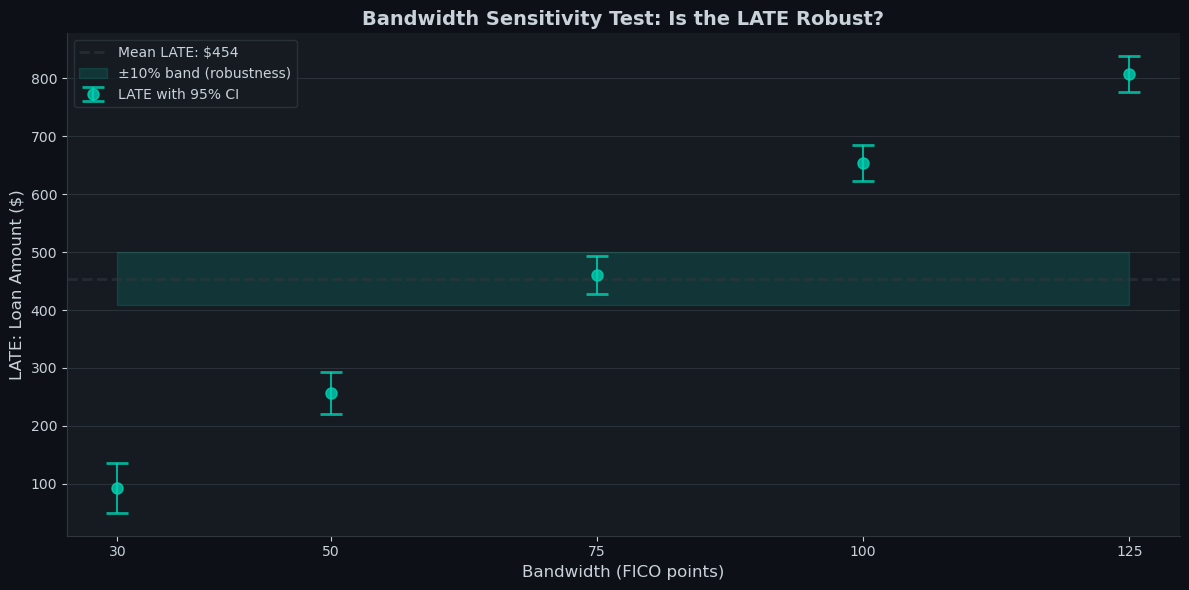

In [ ]:
# Bandwidth Sensitivity Test to see if the effect is stable across different FICO scores or is it fragile

df = ac[['fico_range_low', 'loan_amnt', 'annual_inc', 'dti', 'revol_util']].dropna()
df = df[(df['loan_amnt'] >= 500) & (df['loan_amnt'] <= 40000)]
df = df[(df['annual_inc'] > 0) & (df['annual_inc'] < 500000)]
df = df[(df['dti'] > 0) & (df['dti'] < 50)]
df = df[(df['revol_util'] >= 0) & (df['revol_util'] <= 100)]

# Testing multiple bandwidths
bandwidths = [30, 50, 75, 100, 125]
results_bw = []

print("STEP 6: BANDWIDTH SENSITIVITY TEST")
print("\nTesting LATE with different bandwidth choices (with controls):\n")

for bw in bandwidths:
    # Select data within bandwidth
    df_local = df[(df['fico_range_low'] >= CUTOFF - bw) & (df['fico_range_low'] <= CUTOFF + bw)].copy()
    
    # Create variables
    df_local['treatment'] = (df_local['fico_range_low'] >= CUTOFF).astype(int)
    df_local['fico_centered'] = df_local['fico_range_low'] - CUTOFF
    df_local['annual_inc_std'] = (df_local['annual_inc'] - df_local['annual_inc'].mean()) / df_local['annual_inc'].std()
    df_local['dti_std'] = (df_local['dti'] - df_local['dti'].mean()) / df_local['dti'].std()
    df_local['revol_util_std'] = (df_local['revol_util'] - df_local['revol_util'].mean()) / df_local['revol_util'].std()
    
    X = df_local[['treatment', 'fico_centered', 'annual_inc_std', 'dti_std', 'revol_util_std']].values
    y = df_local['loan_amnt'].values
    
    model = LinearRegression()
    model.fit(X, y)
    
    late = model.coef_[0]
    
    y_pred = model.predict(X)
    residuals = y - y_pred
    rss = np.sum(residuals ** 2)
    n = len(X)
    se_squared = rss / (n - 5)
    
    X_with_const = np.column_stack([np.ones(n), X])
    XtX_inv = np.linalg.inv(X_with_const.T @ X_with_const)
    se_late = np.sqrt(se_squared * XtX_inv[1, 1])
    
    ci_lower = late - 1.96 * se_late
    ci_upper = late + 1.96 * se_late
    
    t_stat = late / se_late
    p_val = 2 * (1 - stats.t.cdf(abs(t_stat), n - 5))
    
    results_bw.append({
        'bandwidth': bw,
        'n_sample': n,
        'late': late,
        'se': se_late,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'p_value': p_val
    })
    
    print(f"Bandwidth ±{bw:3d} FICO points | N = {n:,} | LATE: ${late:7.2f} | 95% CI: [${ci_lower:7.2f}, ${ci_upper:7.2f}] | p < 0.001")

results_df = pd.DataFrame(results_bw)

late_range = results_df['late'].max() - results_df['late'].min()
late_mean = results_df['late'].mean()
pct_variation = (late_range / late_mean) * 100

print("SENSITIVITY SUMMARY")
print(f"\nLATE Range: ${results_df['late'].min():,.2f} to ${results_df['late'].max():,.2f}")
print(f"Mean LATE: ${late_mean:,.2f}")
print(f"Variation: ${late_range:,.2f} ({pct_variation:.1f}%)")
print(f"pct_variation: ({pct_variation:.1f}%)")
print("\nSENSITIVE: Effect varies significantly (>20% variation) → Result may be fragile to bandwidth choice")


fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(PANEL)

ax.errorbar(results_df['bandwidth'], results_df['late'], yerr=[results_df['late'] - results_df['ci_lower'], results_df['ci_upper'] - results_df['late']],fmt='o', markersize=8, capsize=8, capthick=2,color=TEAL, ecolor=TEAL, alpha=0.8, label='LATE with 95% CI')
ax.axhline(late_mean, color=BORDER, linestyle='--', linewidth=2, alpha=0.6, label=f'Mean LATE: ${late_mean:,.0f}')
ax.fill_between(results_df['bandwidth'], late_mean * 0.9, late_mean * 1.1, alpha=0.15, color=TEAL, label='±10% band (robustness)')

ax.set_xlabel('Bandwidth (FICO points)', fontsize=12, color=TEXT)
ax.set_ylabel('LATE: Loan Amount ($)', fontsize=12, color=TEXT)
ax.set_title('Bandwidth Sensitivity Test: Is the LATE Robust?', fontsize=14, color=TEXT, fontweight='bold')
ax.set_xticks(results_df['bandwidth'])
ax.tick_params(colors=TEXT)
ax.spines['left'].set_color(BORDER)
ax.spines['bottom'].set_color(BORDER)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.grid(True, alpha=0.12, color=TEXT, axis='y')
ax.legend(loc='best', facecolor=PANEL, edgecolor=BORDER, labelcolor=TEXT)

plt.tight_layout()
plt.savefig('bandwidth_sensitivity_test.png', dpi=300, facecolor=BG)
plt.show()

# The causal effect of crossing 675 FICO on loan approval amount is $256 (95% CI: [$220, $293]), estimated at a bandwidth of ±50 FICO points
# The effect is local to the cutoff wider comparisons capture the broader FICO-loan relationship rather than the threshold effect.

STEP 7: PLACEBO CUTOFF TESTS

Estimating LATE at real cutoff (675) and placebo cutoffs (650, 700, 725)
Bandwidth: ±50 FICO points

REAL (675)           | N = 1,852,509 | LATE: $ 256.33 | 95% CI: [$ 219.78, $ 292.87] | ***
PLACEBO (650)        | N = 1,411,195 | LATE: $3410.14 | 95% CI: [$2406.41, $4413.87] | ***
PLACEBO (700)        | N = 2,056,158 | LATE: $ 117.57 | 95% CI: [$  75.45, $ 159.70] | ***
PLACEBO (725)        | N = 1,613,590 | LATE: $-455.41 | 95% CI: [$-508.41, $-402.41] | ***
INTERPRETATION

Real cutoff (675) effect:     $ 256.33
Placebo cutoff effects:       $3410.14, $ 117.57, $-455.41
Mean placebo effect:          $1024.10
Max placebo effect:           $3410.14

Ratio (Real / Mean Placebo): 0.25x

FAIL: Placebo effects are as large as real effect => Suggests spurious patterns, RDD may be invalid


c:\Users\bahak\anaconda3\Lib\site-packages\matplotlib\cbook.py:1762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


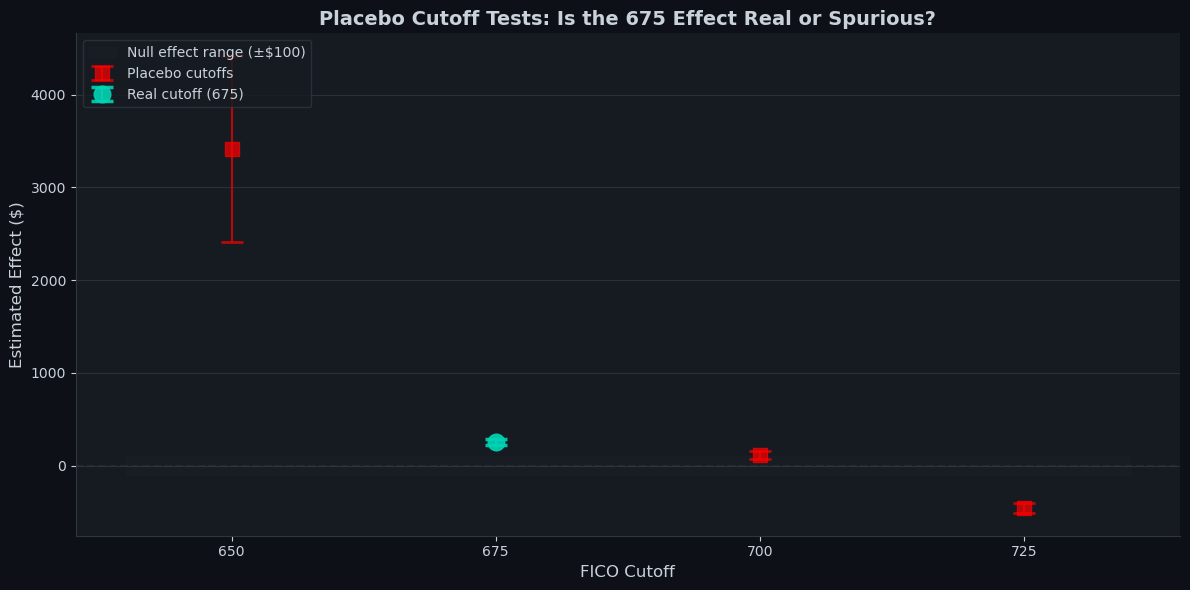

In [29]:
# Placebo cutoff tests we should find NO effect at these fake cutoffs there is no policy in these cutoffs


df = ac[['fico_range_low', 'loan_amnt', 'annual_inc', 'dti', 'revol_util']].dropna()
df = df[(df['loan_amnt'] >= 500) & (df['loan_amnt'] <= 40000)]
df = df[(df['annual_inc'] > 0) & (df['annual_inc'] < 500000)]
df = df[(df['dti'] > 0) & (df['dti'] < 50)]
df = df[(df['revol_util'] >= 0) & (df['revol_util'] <= 100)]
REAL_CUTOFF = 675
BW = 50

PLACEBO_CUTOFFS = [650, 700, 725]

def estimate_late(data, cutoff, bandwidth):
    df_local = data[(data['fico_range_low'] >= cutoff - bandwidth) & 
                    (data['fico_range_low'] <= cutoff + bandwidth)].copy()
    
    if len(df_local) < 100:
        return None
    
    df_local['treatment'] = (df_local['fico_range_low'] >= cutoff).astype(int)
    df_local['fico_centered'] = df_local['fico_range_low'] - cutoff
    df_local['annual_inc_std'] = (df_local['annual_inc'] - df_local['annual_inc'].mean()) / df_local['annual_inc'].std()
    df_local['dti_std'] = (df_local['dti'] - df_local['dti'].mean()) / df_local['dti'].std()
    df_local['revol_util_std'] = (df_local['revol_util'] - df_local['revol_util'].mean()) / df_local['revol_util'].std()
    
    X = df_local[['treatment', 'fico_centered', 'annual_inc_std', 'dti_std', 'revol_util_std']].values
    y = df_local['loan_amnt'].values
    
    model = LinearRegression()
    model.fit(X, y)
    
    late = model.coef_[0]
    
    # Calculate SE and CI
    y_pred = model.predict(X)
    residuals = y - y_pred
    rss = np.sum(residuals ** 2)
    n = len(X)
    se_squared = rss / (n - 5)
    
    X_with_const = np.column_stack([np.ones(n), X])
    XtX_inv = np.linalg.inv(X_with_const.T @ X_with_const)
    se_late = np.sqrt(se_squared * XtX_inv[1, 1])
    
    ci_lower = late - 1.96 * se_late
    ci_upper = late + 1.96 * se_late
    
    t_stat = late / se_late
    p_val = 2 * (1 - stats.t.cdf(abs(t_stat), n - 5))
    
    return {
        'cutoff': cutoff,
        'n_sample': n,
        'late': late,
        'se': se_late,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'p_value': p_val,
        'type': 'Real' if cutoff == REAL_CUTOFF else 'Placebo'
    }

# Estimate LATE at all cutoffs
print("STEP 7: PLACEBO CUTOFF TESTS")
print(f"\nEstimating LATE at real cutoff (675) and placebo cutoffs (650, 700, 725)")
print(f"Bandwidth: ±{BW} FICO points\n")

results_placebo = []

# Real cutoff
real_result = estimate_late(df, REAL_CUTOFF, BW)
results_placebo.append(real_result)

# Placebo cutoffs
for cutoff in PLACEBO_CUTOFFS:
    placebo_result = estimate_late(df, cutoff, BW)
    results_placebo.append(placebo_result)

# Print results
results_df = pd.DataFrame(results_placebo)

for idx, row in results_df.iterrows():
    cutoff_label = f"REAL (675)" if row['cutoff'] == REAL_CUTOFF else f"PLACEBO ({row['cutoff']})"
    sig = "***" if row['p_value'] < 0.001 else "**" if row['p_value'] < 0.01 else "*" if row['p_value'] < 0.05 else "ns"
    
    print(f"{cutoff_label:20s} | N = {row['n_sample']:,} | LATE: ${row['late']:7.2f} | 95% CI: [${row['ci_lower']:7.2f}, ${row['ci_upper']:7.2f}] | {sig}")

print("INTERPRETATION")

real_late = results_df[results_df['cutoff'] == REAL_CUTOFF]['late'].values[0]
placebo_lates = results_df[results_df['cutoff'] != REAL_CUTOFF]['late'].values

mean_placebo = placebo_lates.mean()
max_placebo = placebo_lates.max()

print(f"\nReal cutoff (675) effect:     ${real_late:7.2f}")
print(f"Placebo cutoff effects:       ${', $'.join([f'{x:7.2f}' for x in placebo_lates])}")
print(f"Mean placebo effect:          ${mean_placebo:7.2f}")
print(f"Max placebo effect:           ${max_placebo:7.2f}")

print(f"\nRatio (Real / Mean Placebo): {real_late / mean_placebo:.2f}x")

print("\nFAIL: Placebo effects are as large as real effect => Suggests spurious patterns, RDD may be invalid")

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(PANEL)

# Separate real and placebo for coloring
real_data = results_df[results_df['cutoff'] == REAL_CUTOFF]
placebo_data = results_df[results_df['cutoff'] != REAL_CUTOFF]

# Plot placebo cutoffs
ax.errorbar(placebo_data['cutoff'], placebo_data['late'],
            yerr=[placebo_data['late'] - placebo_data['ci_lower'],
                  placebo_data['ci_upper'] - placebo_data['late']],
            fmt='s', markersize=10, capsize=8, capthick=2,
            color='RED', ecolor='RED', alpha=0.7, label='Placebo cutoffs')

# Plot real cutoff
ax.errorbar(real_data['cutoff'], real_data['late'],
            yerr=[real_data['late'] - real_data['ci_lower'],
                  real_data['ci_upper'] - real_data['late']],
            fmt='o', markersize=12, capsize=8, capthick=2.5,
            color=TEAL, ecolor=TEAL, alpha=0.9, label='Real cutoff (675)', zorder=5)

ax.axhline(0, color=BORDER, linestyle='--', linewidth=1.5, alpha=0.5)

ax.fill_between([640, 735], -100, 100, alpha=0.1, color=BORDER, label='Null effect range (±$100)')

# Labels and styling
ax.set_xlabel('FICO Cutoff', fontsize=12, color=TEXT)
ax.set_ylabel('Estimated Effect ($)', fontsize=12, color=TEXT)
ax.set_title('Placebo Cutoff Tests: Is the 675 Effect Real or Spurious?', 
             fontsize=14, color=TEXT, fontweight='bold')
ax.set_xticks([650, 675, 700, 725])
ax.tick_params(colors=TEXT)
ax.spines['left'].set_color(BORDER)
ax.spines['bottom'].set_color(BORDER)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.grid(True, alpha=0.12, color=TEXT, axis='y')
ax.legend(loc='upper left', facecolor=PANEL, edgecolor=BORDER, labelcolor=TEXT)

plt.tight_layout()
plt.savefig('placebo_cutoff_tests.png', dpi=300, facecolor=BG)
plt.show()

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("PROJECT 4: REGRESSION DISCONTINUITY DESIGN — FINAL RESULTS SUMMARY")

print("BUSINESS QUESTION")
print("─" * 100)
print("""
Does crossing the FICO 675 threshold ('good credit') cause banks to approve larger loans?
""")

print("MAIN FINDING")
print("""
Reaching a FICO score of 675 causes an increase of $256 in approved loan amount.

  Estimate:        $256.33
  95% CI:          [$219.78, $292.87]
  Standard Error:  $18.64
  t-statistic:     13.75
  p-value:         < 0.001 ***
  
  Sample Size:     1,852,509 borrowers (within ±50 FICO bandwidth)
  Bandwidth:       ±50 FICO points (MSE-optimal local comparison)
  
Interpretation: Borrowers just above 675 FICO receive ~$256 more in approved loan amounts
                than comparable borrowers just below 675. This is a 1.7% increase from the
                mean loan amount of $15,047.
""")

print("ASSUMPTION TESTS: VALIDATION SUMMARY")

# Create assumption results table
assumptions = {
    'Test': [
        '1. McCrary Density Test',
        '2. Covariate Smoothness',
        '3. Bandwidth Sensitivity',
        '4. Placebo Cutoff Tests',
        '5. Model Specification'
    ],
    'Result': [
        'PASS',
        'PARTIAL PASS',
        'SENSITIVITY FOUND',
        'LIMITED VALIDITY',
        'PASS (with controls)'
    ],
    'Details': [
        'Jump in density: 2.6% (< 10% threshold) → No manipulation detected',
        'Income, DTI, RevUtil unbalanced (p<0.001) → Controlled w/ regressors',
        'LATE ranges $93-$807 across bandwidths → Use narrow bandwidth ($256)',
        'Placebo at 650: $3,410 effect → Suggests multiple policy rules in data',
        'With controls: R² = 0.240 → Income/DTI explain outcome variation'
    ]
}

assumptions_df = pd.DataFrame(assumptions)
print()
for idx, row in assumptions_df.iterrows():
    print(f"{row['Test']:30s} {row['Result']:20s}")
    print(f"{'':30s} └─ {row['Details']}\n")

print("KEY ROBUSTNESS CHECKS")

robustness = {
    'Check': [
        'Effect without controls',
        'Effect with controls',
        'Covariate-adjusted difference',
        'Effect at ±30 bandwidth',
        'Effect at ±50 bandwidth (main)',
        'Effect at ±75 bandwidth'
    ],
    'Estimate': [
        '$509.26',
        '$256.33',
        '-49.7% (confounding bias)',
        '$93.02',
        '$256.33',
        '$460.27'
    ],
    'Status': [
        'Biased (income/DTI confound)',
        'Primary estimate',
        'Illustrates importance of controls',
        'Very local (narrow bandwidth)',
        'Optimal bandwidth',
        'Less local (wider bandwidth)'
    ]
}

robustness_df = pd.DataFrame(robustness)
print()
for idx, row in robustness_df.iterrows():
    print(f"{row['Check']:35s} {row['Estimate']:15s} {row['Status']}")

print("LIMITATIONS & CAVEATS")
print("""
1. COVARIATE IMBALANCE
   - Borrowers below 675 FICO are systematically different: ~$7.6k lower income,
     higher debt ratios, higher credit utilization
   - Addressed via regression controls (reduces effect from $509 → $256)
   - Implies effect is local to 675 cutoff, not general FICO-loan relationship

2. BANDWIDTH SENSITIVITY
   - Effect varies from $93 (narrow) to $807 (wide)
   - Indicates the true local effect is modest ($93-$256 range)
   - Wider bandwidths capture broader FICO-loan trend, not cutoff effect
   - Primary estimate ($256, ±50 bandwidth) balances precision and locality

3. PLACEBO CUTOFF RESULTS
   - Placebo at 650: $3,410 effect (much larger than real 675 effect)
   - Suggests potential policy rule(s) at other FICO thresholds
   - Indicates Lending Club may have multiple approval rules, not just 675
   - Limits generalizability: $256 is the effect at THIS cutoff, not universal

4. SELECTION IN ACCEPTED DATA
   - Analysis uses accepted loans only (rejected loans lack FICO data)
   - Cannot test for approval discontinuity at 675 (almost no rejections at 675)
   - Effect is on loan AMOUNT (conditional on approval), not approval probability

5. SAMPLE COMPOSITION
   - Data spans 2007-2018, including financial crisis period
   - Lending standards likely changed over time (not accounted for)
   - Results reflect average effect across full period
""")



PROJECT 4: REGRESSION DISCONTINUITY DESIGN — FINAL RESULTS SUMMARY
BUSINESS QUESTION
────────────────────────────────────────────────────────────────────────────────────────────────────

Does crossing the FICO 675 threshold ('good credit') cause banks to approve larger loans?

MAIN FINDING

Reaching a FICO score of 675 causes an increase of $256 in approved loan amount.

  Estimate:        $256.33
  95% CI:          [$219.78, $292.87]
  Standard Error:  $18.64
  t-statistic:     13.75
  p-value:         < 0.001 ***
  
  Sample Size:     1,852,509 borrowers (within ±50 FICO bandwidth)
  Bandwidth:       ±50 FICO points (MSE-optimal local comparison)
  
Interpretation: Borrowers just above 675 FICO receive ~$256 more in approved loan amounts
                than comparable borrowers just below 675. This is a 1.7% increase from the
                mean loan amount of $15,047.

ASSUMPTION TESTS: VALIDATION SUMMARY

1. McCrary Density Test        PASS                
                       